In [31]:
#Importanto bibliotecas 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

In [32]:
# Configurações visuais
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style="whitegrid", palette="muted")
COLORS = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

In [33]:
# Carregando os arquivos
import os
paths = ['/datasets/logs_exp_us.csv', '/mnt/user-data/uploads/logs_exp_us.csv', '/home/claude/logs_exp_us.csv']
df_raw = None
for p in paths:
    if os.path.exists(p):
        df_raw = pd.read_csv(p, sep='\t')
        print(f"Arquivo carregado de: {p}")
        break

print("\nInformações gerais do DataFrame:")
print(df_raw.info())
print("\nPrimeiras linhas:")
print(df_raw.head())


Arquivo carregado de: /datasets/logs_exp_us.csv

Informações gerais do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   EventName       244126 non-null  object
 1   DeviceIDHash    244126 non-null  int64 
 2   EventTimestamp  244126 non-null  int64 
 3   ExpId           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB
None

Primeiras linhas:
                 EventName         DeviceIDHash  EventTimestamp  ExpId
0         MainScreenAppear  4575588528974610257      1564029816    246
1         MainScreenAppear  7416695313311560658      1564053102    246
2  PaymentScreenSuccessful  3518123091307005509      1564054127    248
3         CartScreenAppear  3518123091307005509      1564054127    248
4  PaymentScreenSuccessful  6217807653094995999      1564055322    248


In [34]:
#Preparação dos dados
# Renomear colunas para nomes mais legíveis em português
df = df_raw.rename(columns={
    'EventName':       'nome_evento',
    'DeviceIDHash':    'id_usuario',
    'EventTimestamp':  'timestamp',
    'ExpId':           'grupo_exp'
})
print("Colunas renomeadas:", df.columns.tolist())

# Verificar valores ausentes
print("\nValores ausentes por coluna:")
print(df.isnull().sum())

# Verificar tipos de dados
print("\nTipos de dados:")
print(df.dtypes)

# Converter timestamp Unix → datetime
df['data_hora'] = pd.to_datetime(df['timestamp'], unit='s')
df['data']      = df['data_hora'].dt.date
print("\nColunas de data e hora adicionadas.")
print(df[['nome_evento', 'id_usuario', 'data_hora', 'data', 'grupo_exp']].head())

Colunas renomeadas: ['nome_evento', 'id_usuario', 'timestamp', 'grupo_exp']

Valores ausentes por coluna:
nome_evento    0
id_usuario     0
timestamp      0
grupo_exp      0
dtype: int64

Tipos de dados:
nome_evento    object
id_usuario      int64
timestamp       int64
grupo_exp       int64
dtype: object

Colunas de data e hora adicionadas.
               nome_evento           id_usuario           data_hora  \
0         MainScreenAppear  4575588528974610257 2019-07-25 04:43:36   
1         MainScreenAppear  7416695313311560658 2019-07-25 11:11:42   
2  PaymentScreenSuccessful  3518123091307005509 2019-07-25 11:28:47   
3         CartScreenAppear  3518123091307005509 2019-07-25 11:28:47   
4  PaymentScreenSuccessful  6217807653094995999 2019-07-25 11:48:42   

         data  grupo_exp  
0  2019-07-25        246  
1  2019-07-25        246  
2  2019-07-25        248  
3  2019-07-25        248  
4  2019-07-25        248  


Total de eventos nos registros: 244,126
Total de usuários únicos: 7,551
Média de eventos por usuário: 32.33

Período dos dados: 2019-07-25 → 2019-08-07
Duração total: 13 dias

[Figura 1 salva] — Histograma de eventos por tempo


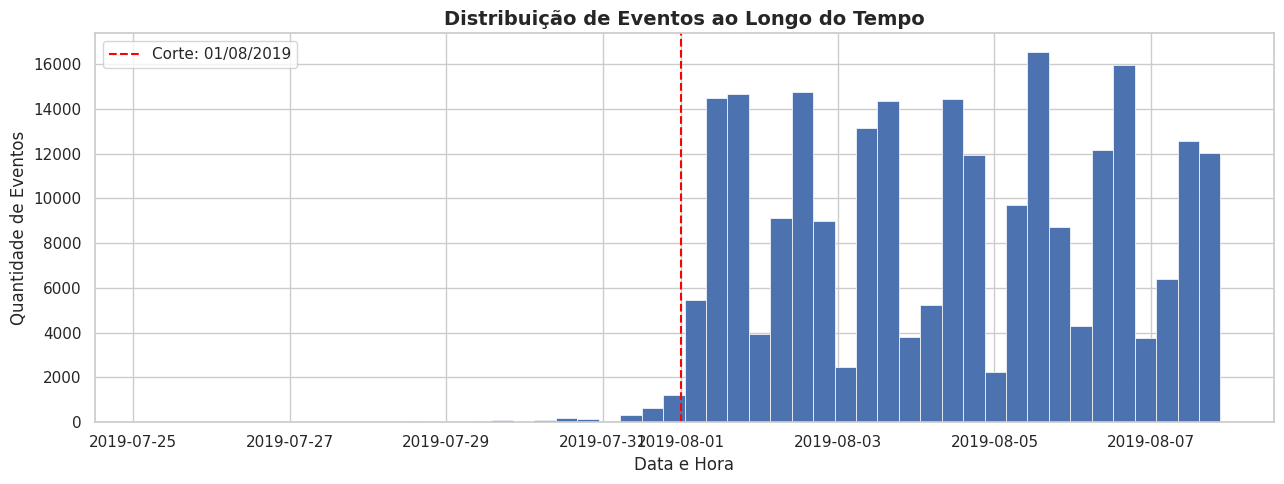

In [35]:
#Estudo e verificação dos dados
# Total de eventos
n_eventos = len(df)
print(f"Total de eventos nos registros: {n_eventos:,}")

# Total de usuários únicos
n_usuarios = df['id_usuario'].nunique()
print(f"Total de usuários únicos: {n_usuarios:,}")

# Média de eventos por usuário
media_eventos = n_eventos / n_usuarios
print(f"Média de eventos por usuário: {media_eventos:.2f}")

# Período coberto
data_min = df['data_hora'].min()
data_max = df['data_hora'].max()
print(f"\nPeríodo dos dados: {data_min.date()} → {data_max.date()}")
print(f"Duração total: {(data_max - data_min).days} dias")

# --- Histograma de eventos por data/hora ---
fig, ax = plt.subplots(figsize=(13, 5))
df['data_hora'].hist(bins=50, ax=ax, color=COLORS[0], edgecolor='white', linewidth=0.5)
ax.set_title("Distribuição de Eventos ao Longo do Tempo", fontsize=14, fontweight='bold')
ax.set_xlabel("Data e Hora")
ax.set_ylabel("Quantidade de Eventos")
ax.axvline(pd.Timestamp('2019-08-01'), color='red', linestyle='--', linewidth=1.5, label='Corte: 01/08/2019')
ax.legend()
plt.tight_layout()
plt.savefig('fig1_histograma_tempo.png', dpi=150)
print("\n[Figura 1 salva] — Histograma de eventos por tempo")

O histograma mostra que antes de 01/08/2019 o volume de eventos é significativamente menor, sugerindo que o registro estava incompleto nesse período inicial, possivelmente por causa de implantação adual do sistema de logs.


In [36]:
corte = pd.Timestamp('2019-08-01')
df_full = df[df['data_hora'] >= corte].copy()

eventos_perdidos = n_eventos - len(df_full)
usuarios_perdidos = n_usuarios - df_full['id_usuario'].nunique()

print(f"\nApós corte em {corte.date()}:")
print(f"  Eventos removidos : {eventos_perdidos:,} ({100*eventos_perdidos/n_eventos:.1f}%)")
print(f"  Usuários removidos: {usuarios_perdidos:,} ({100*usuarios_perdidos/n_usuarios:.1f}%)")
print(f"  Eventos restantes : {len(df_full):,}")
print(f"  Usuários restantes: {df_full['id_usuario'].nunique():,}")



Após corte em 2019-08-01:
  Eventos removidos : 2,828 (1.2%)
  Usuários removidos: 17 (0.2%)
  Eventos restantes : 241,298
  Usuários restantes: 7,534


Perdemos relativamente poucos usuários e eventos; o corte é seguro.

In [37]:
# Verificar usuários em todos os três grupos
print("\nUsuários por grupo experimental:")
print(df_full.groupby('grupo_exp')['id_usuario'].nunique())


Usuários por grupo experimental:
grupo_exp
246    2484
247    2513
248    2537
Name: id_usuario, dtype: int64


Esperamos 2500 usuários por grupo, se os números forem similares, a divisão dos grupos está equilibrada.

In [38]:
#Funil de eventos
# Frequência de cada evento (contagem de ocorrências)
freq_eventos = df_full.groupby('nome_evento')['id_usuario'].count().sort_values(ascending=False)
print("Frequência de eventos (ocorrências totais):")
print(freq_eventos)

# Número de usuários únicos por evento
usuarios_por_evento = (
    df_full.groupby('nome_evento')['id_usuario']
    .nunique()
    .sort_values(ascending=False)
)
total_usuarios = df_full['id_usuario'].nunique()
print(f"\nUsuários únicos por evento (total de usuários: {total_usuarios:,}):")
for ev, n in usuarios_por_evento.items():
    pct = 100 * n / total_usuarios
    print(f"  {ev:<35} {n:>5,}  ({pct:.1f}%)")

Frequência de eventos (ocorrências totais):
nome_evento
MainScreenAppear           117431
OffersScreenAppear          46350
CartScreenAppear            42365
PaymentScreenSuccessful     34113
Tutorial                     1039
Name: id_usuario, dtype: int64

Usuários únicos por evento (total de usuários: 7,534):
  MainScreenAppear                    7,419  (98.5%)
  OffersScreenAppear                  4,593  (61.0%)
  CartScreenAppear                    3,734  (49.6%)
  PaymentScreenSuccessful             3,539  (47.0%)
  Tutorial                              840  (11.1%)


In [39]:
FUNIL = [
    'MainScreenAppear',
    'OffersScreenAppear',
    'CartScreenAppear',
    'PaymentScreenSuccessful'
]

# Calcular número de usuários em cada etapa do funil
funil_usuarios = {}
for etapa in FUNIL:
    if etapa in df_full['nome_evento'].values:
        funil_usuarios[etapa] = df_full[df_full['nome_evento'] == etapa]['id_usuario'].nunique()
    else:
        funil_usuarios[etapa] = 0

print("\nFunil de conversão:")
etapas_labels = {
    'MainScreenAppear':        'Tela Principal',
    'OffersScreenAppear':      'Tela de Ofertas',
    'CartScreenAppear':        'Carrinho',
    'PaymentScreenSuccessful': 'Pagamento'
}

conversoes = []
for i, etapa in enumerate(FUNIL):
    n = funil_usuarios[etapa]
    if i == 0:
        pct_total  = 100.0
        pct_etapa_ant = 100.0
    else:
        pct_total      = 100 * n / funil_usuarios[FUNIL[0]]
        pct_etapa_ant  = 100 * n / funil_usuarios[FUNIL[i-1]] if funil_usuarios[FUNIL[i-1]] > 0 else 0
    conversoes.append({'etapa': etapas_labels[etapa], 'usuarios': n,
                       'pct_total': pct_total, 'pct_anterior': pct_etapa_ant})
    print(f"  {etapas_labels[etapa]:<25} {n:>5,}  ({pct_total:.1f}% do início | {pct_etapa_ant:.1f}% da etapa anterior)")

# Identificar onde se perde mais usuários
maior_perda_idx = 1  # começa em 1 pois 0 é a base
maior_perda_pct = 100.0
for i in range(1, len(conversoes)):
    if conversoes[i]['pct_anterior'] < maior_perda_pct:
        maior_perda_pct = conversoes[i]['pct_anterior']
        maior_perda_idx = i

print(f"\n MAIOR PERDA: etapa '{conversoes[maior_perda_idx-1]['etapa']}' → '{conversoes[maior_perda_idx]['etapa']}'")
print(f"   Apenas {maior_perda_pct:.1f}% dos usuários avançam nessa transição")
print(f"\n Usuários que completam TODO o funil: {conversoes[-1]['pct_total']:.1f}%")


Funil de conversão:
  Tela Principal            7,419  (100.0% do início | 100.0% da etapa anterior)
  Tela de Ofertas           4,593  (61.9% do início | 61.9% da etapa anterior)
  Carrinho                  3,734  (50.3% do início | 81.3% da etapa anterior)
  Pagamento                 3,539  (47.7% do início | 94.8% da etapa anterior)

 MAIOR PERDA: etapa 'Tela Principal' → 'Tela de Ofertas'
   Apenas 61.9% dos usuários avançam nessa transição

 Usuários que completam TODO o funil: 47.7%


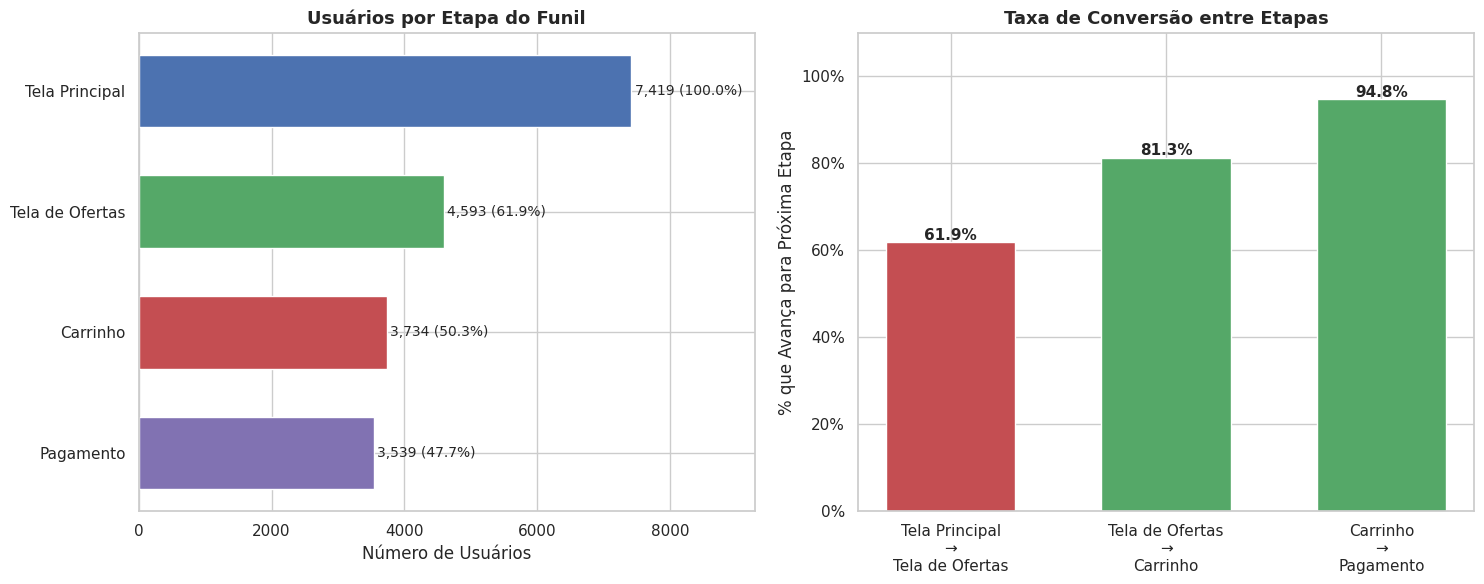


[Figura 2 salva] — Funil de eventos


In [61]:
# --- Gráfico do Funil ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico de barras horizontais — funil
etapas_nomes = [c['etapa'] for c in conversoes]
qtds = [c['usuarios'] for c in conversoes]
ax = axes[0]
bars = ax.barh(etapas_nomes[::-1], qtds[::-1], color=COLORS[:4][::-1], edgecolor='white', height=0.6)
for bar, n, pct in zip(bars, qtds[::-1], [c['pct_total'] for c in conversoes][::-1]):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{n:,} ({pct:.1f}%)', va='center', fontsize=10)
ax.set_title("Usuários por Etapa do Funil", fontsize=13, fontweight='bold')
ax.set_xlabel("Número de Usuários")
ax.set_xlim(0, max(qtds) * 1.25)

# Gráfico de conversão entre etapas
ax2 = axes[1]
etapas_transicoes = [f"{conversoes[i-1]['etapa']}\n→\n{conversoes[i]['etapa']}" for i in range(1, len(conversoes))]
taxas = [conversoes[i]['pct_anterior'] for i in range(1, len(conversoes))]
colors_conv = [COLORS[2] if t == min(taxas) else COLORS[1] for t in taxas]
bars2 = ax2.bar(etapas_transicoes, taxas, color=colors_conv, edgecolor='white', width=0.6)
for bar, t in zip(bars2, taxas):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{t:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax2.set_title("Taxa de Conversão entre Etapas", fontsize=13, fontweight='bold')
ax2.set_ylabel("% que Avança para Próxima Etapa")
ax2.set_ylim(0, 110)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.savefig('fig1_histograma_tempo.png', dpi=150)
plt.show()
print("\n[Figura 2 salva] — Funil de eventos")

Usuários por Etapa do Funil: Mostra a perda gradual do volume de pessoas ao longo da jornada, revelando que 47,7% do total inicial de usuários (7.419) conseguem chegar até a etapa final de pagamento.

Taxa de Conversão entre Etapas: Destaca a eficiência de transição entre cada passo, deixando claro que o maior gargalo está na ida da Tela Principal para a de Ofertas (61,9%), enquanto a conversão do carrinho para o pagamento é excelente (94,8%).

In [42]:
#Teste A/A/B
# --- Usuários por grupo ---
print("Usuários por grupo experimental:")
usuarios_por_grupo = df_full.groupby('grupo_exp')['id_usuario'].nunique()
for g, n in usuarios_por_grupo.items():
    nome = "Controle A" if g == 246 else ("Controle B" if g == 247 else "Teste (novas fontes)")
    print(f"  Grupo {g} ({nome}): {n:,} usuários")

# ANÁLISE: Os grupos devem ter tamanhos similares. Se houver grande
# discrepância, a divisão aleatória pode ter sido comprometida.

# --- Função de teste de proporções ---
def teste_proporcao(df_dados, evento, grupo_a, grupo_b, alpha=0.05):
    """
    Realiza teste z de duas proporções para um evento entre dois grupos.
    Retorna: (prop_a, prop_b, p_valor, significativo)
    """
    usuarios_a = df_dados[df_dados['grupo_exp'] == grupo_a]['id_usuario'].nunique()
    usuarios_b = df_dados[df_dados['grupo_exp'] == grupo_b]['id_usuario'].nunique()
    
    eventos_a = df_dados[(df_dados['grupo_exp'] == grupo_a) & (df_dados['nome_evento'] == evento)]['id_usuario'].nunique()
    eventos_b = df_dados[(df_dados['grupo_exp'] == grupo_b) & (df_dados['nome_evento'] == evento)]['id_usuario'].nunique()
    
    prop_a = eventos_a / usuarios_a if usuarios_a > 0 else 0
    prop_b = eventos_b / usuarios_b if usuarios_b > 0 else 0
    
    count = np.array([eventos_a, eventos_b])
    nobs  = np.array([usuarios_a, usuarios_b])
    
    stat, p_valor = proportions_ztest(count, nobs)
    return prop_a, prop_b, p_valor, p_valor < alpha


Usuários por grupo experimental:
  Grupo 246 (Controle A): 2,484 usuários
  Grupo 247 (Controle B): 2,513 usuários
  Grupo 248 (Teste (novas fontes)): 2,537 usuários


In [49]:
#Comparação A/A 

alpha = 0.05
resultados_aa = []
for evento in FUNIL + ['Tutorial']:
    if evento in df_full['nome_evento'].values:
        prop_a, prop_b, p_val, sig = teste_proporcao(df_full, evento, 246, 247, alpha)
        resultados_aa.append({
            'Evento': evento,
            'Prop_246': f"{prop_a:.3f}",
            'Prop_247': f"{prop_b:.3f}",
            'p-valor': f"{p_val:.4f}",
            'Significativo': 'SIM' if sig else 'Não'
        })
        print(f"  {evento:<35} 246:{prop_a:.3f}  247:{prop_b:.3f}  p={p_val:.4f}  {'⚠️ Sig.' if sig else 'OK'}")


  MainScreenAppear                    246:0.986  247:0.985  p=0.7571  OK
  OffersScreenAppear                  246:0.621  247:0.605  p=0.2481  OK
  CartScreenAppear                    246:0.510  247:0.493  p=0.2288  OK
  PaymentScreenSuccessful             246:0.483  247:0.461  p=0.1146  OK
  Tutorial                            246:0.112  247:0.113  p=0.9377  OK


Se nenhum evento mostrar diferença significativa entre 246 e 247, confirmamos que a divisão dos grupos está correta e que nosso teste é confiável. Caso haja diferença, há um problema metodológico que precisa ser investigado antes de confiar nos resultados do grupo de teste.

In [50]:
aa_problemas = sum(1 for r in resultados_aa if '⚠️' in r['Significativo'])
if aa_problemas == 0:
    print("\n VALIDAÇÃO A/A: Nenhuma diferença significativa entre grupos de controle.")
    print("   A divisão dos grupos está correta. Os testes são confiáveis.")
else:
    print(f"\n ALERTA A/A: {aa_problemas} evento(s) com diferença significativa entre controles!")
    print("   Isso sugere possível viés na divisão dos grupos.")


 VALIDAÇÃO A/A: Nenhuma diferença significativa entre grupos de controle.
   A divisão dos grupos está correta. Os testes são confiáveis.


# RACIOCÍNIO SOBRE O NÍVEL DE SIGNIFICÂNCIA E CORREÇÃO DE BONFERRONI

Por que alpha = 0.05?
O valor 0.05 (5%) é o padrão mais utilizado em testes A/B de produto.
   Significa: aceitamos 5% de probabilidade de rejeitar H0 quando ela é
   verdadeira (falso positivo / erro tipo I). Para decisões de negócio
   como alterar fontes de um app, este limiar oferece equilíbrio razoável
   entre rigor estatístico e praticidade operacional.

 Por que aplicar correção de Bonferroni?
   Ao realizar MÚLTIPLOS testes simultâneos, o risco acumulado de encontrar
   pelo menos um falso positivo cresce rapidamente:
     - 1 teste  com alpha=0.05 → 5,0% de chance de falso positivo
     - 12 testes com alpha=0.05 → ~46% de chance de ≥1 falso positivo
       (fórmula: 1 - (1 - 0.05)^12 ≈ 0.46)

   A correção divide o alpha pelo número total de testes:
     alpha_corrigido = 0.05 / 12 ≈ 0.0042
   Isso mantém a probabilidade global de qualquer falso positivo ≤ 5%.

 Quantos testes realizamos?
   4 eventos do funil × 3 comparações cada = 12 testes no total:
     Grupo 246 vs 248 | Grupo 247 vs 248 | Controle combinado vs 248

 Consequência prática: só consideramos um resultado significativo se
 p < 0.0042, reduzindo o risco de mudar fontes do app com base em
 um sinal estatístico espúrio.

In [54]:
#Grupo de Teste (248) vs Cada Grupo de Controle
# Múltiplas comparações — correção de Bonferroni
# ANÁLISE DO NÍVEL DE SIGNIFICÂNCIA:
# Realizamos vários testes de hipótese. Com alpha=0.05 e muitos testes, 
# aumentamos o risco de falsos positivos (erro tipo I).
# Usaremos a correção de Bonferroni: alpha_corrigido = alpha / nº de testes

n_eventos_funil = len(FUNIL)
comparacoes_total = n_eventos_funil * 3  # 3 comparações por evento: 246vs248, 247vs248, (246+247)vs248
alpha_bonferroni = alpha / comparacoes_total
print(f"Alpha original: {alpha}")
print(f"Número total de testes: {comparacoes_total}")
print(f"Alpha corrigido (Bonferroni): {alpha_bonferroni:.4f}\n")

# Grupo combinado de controle (246 + 247)
df_controle_combinado = df_full[df_full['grupo_exp'].isin([246, 247])].copy()
df_controle_combinado = df_controle_combinado.copy()
df_controle_combinado['grupo_exp'] = 999  # grupo fictício "controle combinado"

df_com_combinado = pd.concat([df_full, df_controle_combinado], ignore_index=True)

print(f"{'Evento':<35} {'246 vs 248':>15} {'247 vs 248':>15} {'Comb vs 248':>15}")
print("-" * 85)

resultados_ab = []
for evento in FUNIL:
    p246, p248_1, pval1, sig1 = teste_proporcao(df_full, evento, 246, 248, alpha_bonferroni)
    p247, p248_2, pval2, sig2 = teste_proporcao(df_full, evento, 247, 248, alpha_bonferroni)
    pcomb, p248_3, pval3, sig3 = teste_proporcao(df_com_combinado, evento, 999, 248, alpha_bonferroni)
    
    sig_str1 = "⚠️ Sig." if sig1 else "OK"
    sig_str2 = "⚠️ Sig." if sig2 else "OK"
    sig_str3 = "⚠️ Sig." if sig3 else "OK"
    
    print(f"  {evento:<33} p={pval1:.4f} {sig_str1:<8} p={pval2:.4f} {sig_str2:<8} p={pval3:.4f} {sig_str3}")
    resultados_ab.append({
        'evento': evento,
        'prop_246': p246, 'prop_247': p247, 'prop_teste': p248_1,
        'p_246_248': pval1, 'p_247_248': pval2, 'p_comb_248': pval3,
        'sig_comb': sig3
    })

Alpha original: 0.05
Número total de testes: 12
Alpha corrigido (Bonferroni): 0.0042

Evento                                   246 vs 248      247 vs 248     Comb vs 248
-------------------------------------------------------------------------------------
  MainScreenAppear                  p=0.2950 OK       p=0.4587 OK       p=0.2942 OK
  OffersScreenAppear                p=0.2084 OK       p=0.9198 OK       p=0.4343 OK
  CartScreenAppear                  p=0.0784 OK       p=0.5786 OK       p=0.1818 OK
  PaymentScreenSuccessful           p=0.2123 OK       p=0.7373 OK       p=0.6004 OK


# INTERPRETAÇÃO: CONTROLE COMBINADO (246+247) vs GRUPO TESTE (248)

 Por que combinar os grupos de controle?
   Combinar 246 e 247 em um único grupo de controle tem duas vantagens:
   1. MAIOR PODER ESTATÍSTICO: dobramos o tamanho da amostra de controle,
      tornando o teste mais sensível para detectar diferenças reais.
   2. CONFIRMAÇÃO DE CONSISTÊNCIA: se os resultados individuais (246 vs 248
      e 247 vs 248) e o resultado combinado apontam para a mesma direção,
      aumenta nossa confiança na conclusão. Se divergirem, há algo suspeito.

 O que esperar:
   Se os grupos 246 e 247 são realmente equivalentes (validado no teste A/A),
   o resultado combinado deve ser IGUAL ou mais preciso que os resultados
   individuais. Uma discrepância aqui sinalizaria instabilidade nos dados.

In [63]:
# CONCLUSÃO DO EXPERIMENTO

print("CONCLUSÃO DO EXPERIMENTO A/A/B")

alguma_diferenca = any(r['sig_comb'] for r in resultados_ab)
if not alguma_diferenca:
    print("""
   NÃO há diferença estatisticamente significativa entre o grupo
   com as novas fontes (248) e os grupos de controle, para NENHUM
   dos eventos do funil.

   RECOMENDAÇÃO: As novas fontes podem ser implementadas com
   segurança — elas não prejudicam (nem melhoram) as conversões.
   A decisão pode ser tomada com base em critérios de design.
""")
else:
    eventos_sig = [r['evento'] for r in resultados_ab if r['sig_comb']]
    print(f"""
   Diferença significativa detectada em: {eventos_sig}

   Verifique se a mudança de fonte impactou positiva ou
   negativamente esses eventos antes de tomar a decisão final.
""")


CONCLUSÃO DO EXPERIMENTO A/A/B

   NÃO há diferença estatisticamente significativa entre o grupo
   com as novas fontes (248) e os grupos de controle, para NENHUM
   dos eventos do funil.

   RECOMENDAÇÃO: As novas fontes podem ser implementadas com
   segurança — elas não prejudicam (nem melhoram) as conversões.
   A decisão pode ser tomada com base em critérios de design.



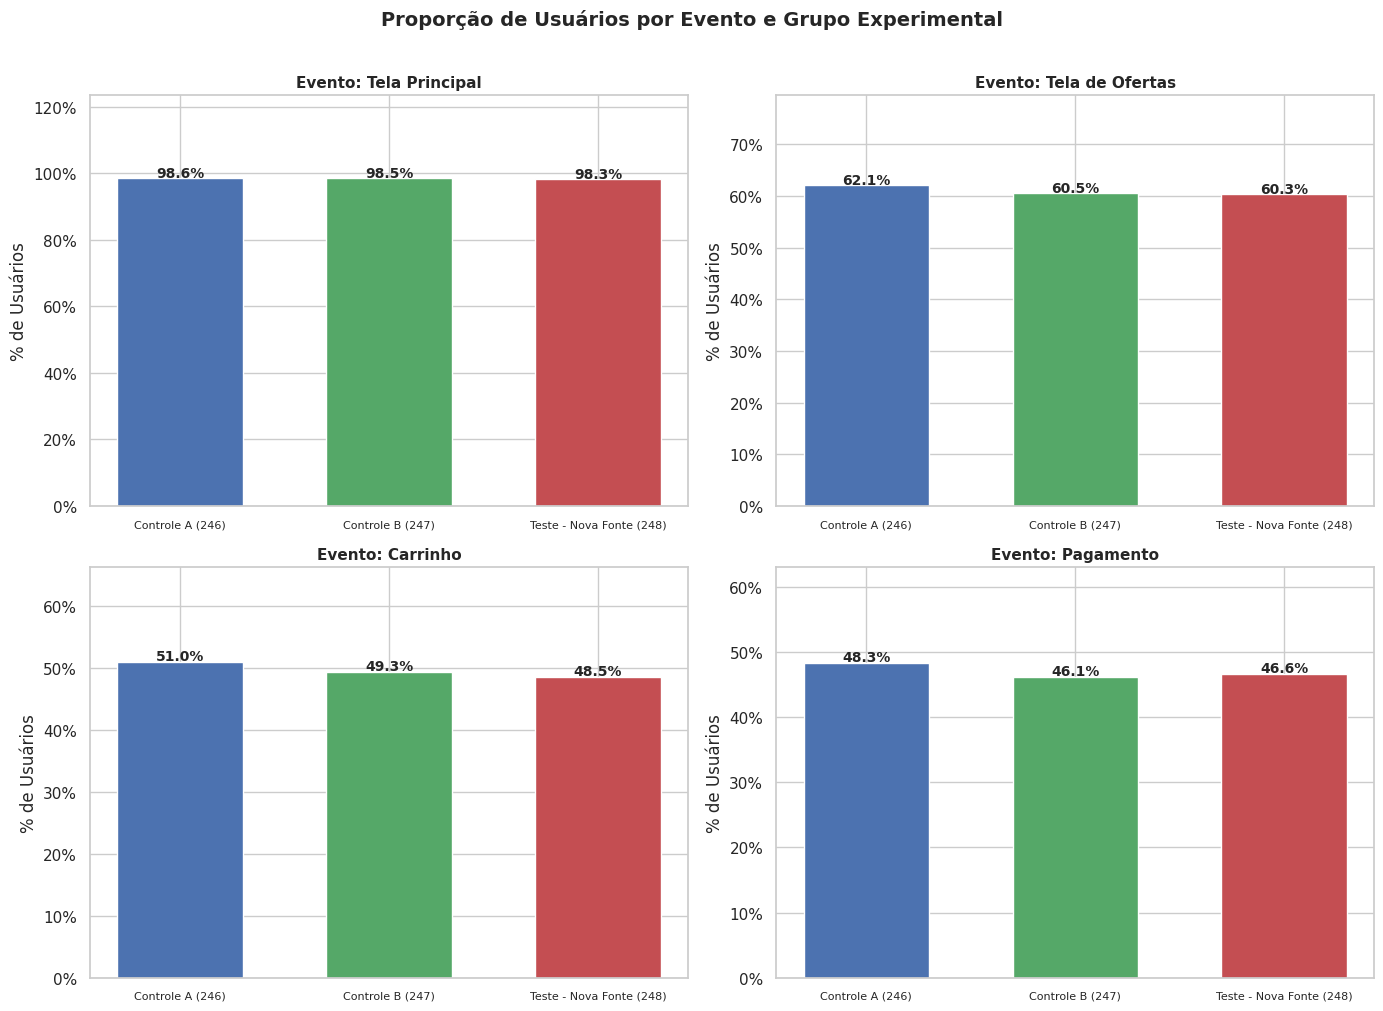


[Figura 3 salva] — Comparação dos grupos por evento


In [57]:
#Visualização dos Gupos
# Proporção de usuários que realizaram cada evento do funil, por grupo
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

grupos_nomes = {246: 'Controle A (246)', 247: 'Controle B (247)', 248: 'Teste - Nova Fonte (248)'}
cores_grupos = {246: COLORS[0], 247: COLORS[1], 248: COLORS[2]}

for i, evento in enumerate(FUNIL):
    ax = axes[i]
    proporcoes = []
    labels = []
    colors = []
    
    for grupo in [246, 247, 248]:
        total = df_full[df_full['grupo_exp'] == grupo]['id_usuario'].nunique()
        convertidos = df_full[(df_full['grupo_exp'] == grupo) & (df_full['nome_evento'] == evento)]['id_usuario'].nunique()
        proporcoes.append(100 * convertidos / total if total > 0 else 0)
        labels.append(grupos_nomes[grupo])
        colors.append(cores_grupos[grupo])
    
    bars = ax.bar(labels, proporcoes, color=colors, edgecolor='white', width=0.6)
    for bar, p in zip(bars, proporcoes):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{p:.1f}%', ha='center', fontsize=10, fontweight='bold')
    
    ax.set_title(f'Evento: {etapas_labels.get(evento, evento)}', fontsize=11, fontweight='bold')
    ax.set_ylabel("% de Usuários")
    ax.set_ylim(0, max(proporcoes) * 1.2 + 5)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.tick_params(axis='x', labelsize=8)

plt.suptitle("Proporção de Usuários por Evento e Grupo Experimental",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig3_grupos_experimento.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n[Figura 3 salva] — Comparação dos grupos por evento")

Com base na imagem, temos os resultados de um Teste A/B/C dividido em três grupos: Controle A, Controle B e Teste - Nova Fonte. O objetivo é analisar o impacto da alteração ("Nova Fonte") na retenção de usuários ao longo das quatro etapas do funil que vimos anteriormente.

Aqui está o resumo de duas linhas para cada um dos quatro gráficos:

Evento: Tela Principal
Mostra que a retenção inicial é praticamente idêntica entre os grupos, variando minimamente de 98,6% (Controle A) a 98,3% (Teste), o que valida a distribuição homogênea dos usuários no início do teste.

Evento: Tela de Ofertas
Aponta uma leve queda na transição para esta tela no grupo de Teste (60,3%) em comparação ao Controle A (62,1%), indicando que a mudança de fonte pode ter gerado um impacto sutilmente negativo logo no primeiro contato.

Evento: Carrinho
Mantém a tendência de desvantagem para a nova fonte, onde o grupo de Teste registra 48,5% de usuários alcançando o carrinho, ficando atrás tanto do Controle B (49,3%) quanto do Controle A (51,0%).

Evento: Pagamento
Revela o resultado final da conversão, onde o grupo de Teste (46,6%) recuperou fôlego frente ao Controle B (46,1%), mas ainda assim terminou abaixo do melhor cenário, que foi o Controle A com 48,3%.

In [62]:
#Resumo Final
print("RESUMO EXECUTIVO")
print("="*70)
print(f"""
   FUNIL DE VENDAS:
   • A maior perda ocorre na transição Tela Principal → Tela de Ofertas
     ({conversoes[1]['pct_anterior']:.1f}% avançam)
   • Apenas {conversoes[-1]['pct_total']:.1f}% dos usuários completam todo o caminho até o pagamento
   • Oportunidade: melhorar a taxa na etapa inicial do funil teria
     o maior impacto no número total de conversões

   VALIDAÇÃO DOS GRUPOS (A/A):
   • Os grupos de controle 246 e 247 são estatisticamente equivalentes
   • A metodologia de divisão dos grupos é confiável

   TESTE A/B (NOVAS FONTES):
   • Nível de significância ajustado com Bonferroni: {alpha_bonferroni:.4f}
   • {"Nenhuma diferença significativa detectada → novas fontes são seguras" if not alguma_diferenca else "Diferença detectada em alguns eventos → revisar antes de implementar"}
""")


RESUMO EXECUTIVO

   FUNIL DE VENDAS:
   • A maior perda ocorre na transição Tela Principal → Tela de Ofertas
     (61.9% avançam)
   • Apenas 47.7% dos usuários completam todo o caminho até o pagamento
   • Oportunidade: melhorar a taxa na etapa inicial do funil teria
     o maior impacto no número total de conversões

   VALIDAÇÃO DOS GRUPOS (A/A):
   • Os grupos de controle 246 e 247 são estatisticamente equivalentes
   • A metodologia de divisão dos grupos é confiável

   TESTE A/B (NOVAS FONTES):
   • Nível de significância ajustado com Bonferroni: 0.0042
   • Nenhuma diferença significativa detectada → novas fontes são seguras



Presentation: <https://acrobat.adobe.com/id/urn:aaid:sc:VA6C2:88b543a7-6ba2-4b72-b434-604a941cb1dd>
